Test cases:

0. No DM- ions should stay at equilibrium position
1. DM moves very very slowly- The force applied to the ions is quasi-static (compared to trap frequencies). We expect to see no excitation but shifting equilibrium position. 
2. DM moves very very quickly. Force is like a delta function. As force approaches delta function, the smaller the kick is. We expect the interaction to resemble the Rutherford scattering. 
3. DM moves at a speed such that interaction time with ions ~1/omega. The ions should have maximum amplitude.  

In [35]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e

eps = 1e-6
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
delta_ion_2 = 0#-4.9903032463e-14 # small displacement of ion 2
m_dm = 1e-27
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
hbar = 1.0545718e-34 
mode_y = 2*pi*np.array([3031200.01,2944587.06,2818861.50])
mode_z = 2*pi*np.array([3002153.56,2914677.59,2787603.39])

In [36]:
# RF pseudo-force
def FRF(x,y,z,m=c.m,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    # --- FORCE EVERYTHING TO SCALARS ---
    x = float(x)
    y = float(y)
    z = float(z)
    m = float(np.asarray(m).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    Zc = float(np.asarray(Z_charge).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z_charge*q)/(2*pi*np.sqrt(m)*omrf))**2*np.array([divypartz*0,divzparty+divyparty,divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,x,y,z,v): # gradient term of DC potential
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.array([divx,divy,divz])

def FDC_single(x1,y1,x2,y2,x,y,z,v):
    return -Z_charge*e * (anatangrad(x2,y2,x,y,z,v)-anatangrad(x2,y1,x,y,z,v)-anatangrad(x1,y2,x,y,z,v)+anatangrad(x1,y1,x,y,z,v))

def FDC(x, y, z, m=c.m, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    z_original = z
    force = np.zeros(3, dtype=float)
    # local copies forced to scalars (if these could be arrays)
    x = float(x); y = float(y); z_original = float(z_original)
    for k in range(0, 40):
        if (k != 19 and k != 39):
            z = z_original - z_offset  # keep scalar math
        else:
            z = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, x, y, z, v_k)
        # ensure force_single is shape (3,)
        force_single = np.asarray(force_single, dtype=float).ravel()
        if force_single.shape != (3,):
            raise ValueError(f"FDC_single returned unexpected shape {force_single.shape} at k={k}")
        force += force_single
        # restore z (already set above each iteration; explicit restore optional)
        z = z_original
    return force

# Full Simulation Code

In [38]:
### Combined simulation code (from combined_full_simulation.ipynb)
def run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=1e-13, atol=1e-16):
    """
    Run the coupled ion-chain / dark-matter trajectory simulation.

    Parameters
    ----------
    x0_dm : array-like, shape (3,)
        Initial position of the dark matter particle.
    v0_dm : array-like, shape (3,)
        Initial velocity of the dark matter particle.
    x0_ions : array-like, shape (3, 3)
        Initial positions of the 3 ions (rows = ions, columns = x,y,z).
        Used to build the initial state vector U0.
    v0_ions : array-like, shape (3, 3)
        Initial velocities of the 3 ions.
    t_span : tuple (t_start, t_end)
        Start and end time of the integration.
    dt : float
        Time increment used to build the evaluation grid
        (t_eval = arange(t_start, t_end, dt)).

    Returns
    -------
    t_eval : ndarray
        Times at which the solution was evaluated.
    x_dm_sol : ndarray, shape (3, N)
        DM position trajectory.
    v_dm_sol : ndarray, shape (3, N)
        DM velocity trajectory.
    x_ions_sol : ndarray, shape (9, N)
        Ion position trajectories (flattened, 3 ions x 3 coords).
    """

    x0_dm   = np.asarray(x0_dm, dtype=float)
    v0_dm   = np.asarray(v0_dm, dtype=float)
    x0_ions = np.asarray(x0_ions, dtype=float)
    v0_ions = np.asarray(v0_ions, dtype=float)

    # Trap restoring force pulls every ion toward the origin (the trap's
    # null point). Equilibrium chain spacing emerges from the balance
    # between this confinement and ion-ion Coulomb repulsion -- it is
    # NOT imposed here.
    r_ions_eq = np.zeros((3, 3), dtype=float)

    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        n_ions = 3

        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM always uses full field) ---
        dc_dm = np.asarray(FDC(*x_dm))
        rf_dm = np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):

            if use_harmonic_ions:
                # Linearized trap around the origin (trap's true center)
                dv_ionsdt[i] += -omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                # Full trap field (same as DM but charge Z*e)
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)

            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            dv_dmdt      -= force / m_dm   # enforce symmetry

            # --- Coulomb: ion <-> ion ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)

                fij = K * e**2 * delta_ij / r_ij**3

                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Build time grid from t_span and dt
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                     t_eval=t_eval, dense_output=True,
                     rtol=rtol, atol=atol, args=(r_ions_eq,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol, v_ions_sol

def run_simulation_rutherford(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=1e-13, atol=1e-16):
    """
    Run the coupled ion-chain / dark-matter trajectory simulation with one ion without trap potential.
    """

    x0_dm   = np.asarray(x0_dm, dtype=float)
    v0_dm   = np.asarray(v0_dm, dtype=float)
    x0_ions = np.asarray(x0_ions, dtype=float)
    v0_ions = np.asarray(v0_ions, dtype=float)

    # Trap restoring force pulls every ion toward the origin (the trap's
    # null point). Equilibrium chain spacing emerges from the balance
    # between this confinement and ion-ion Coulomb repulsion -- it is
    # NOT imposed here.
    r_ions_eq = np.zeros((1,3), dtype=float) # np.zeros((3, 3), dtype=float)

    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        n_ions = 1 #3

        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM always uses full field) ---
        dc_dm = 0 #np.asarray(FDC(*x_dm))
        rf_dm = 0 #np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):

            if use_harmonic_ions:
                # Linearized trap around the origin (trap's true center)
                dv_ionsdt[i] += 0 #-omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                # Full trap field (same as DM but charge Z*e)
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)

            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            dv_dmdt      -= force / m_dm   # enforce symmetry

            # --- Coulomb: ion <-> ion ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)

                fij = K * e**2 * delta_ij / r_ij**3

                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Build time grid from t_span and dt
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                     t_eval=t_eval, dense_output=True,
                     rtol=rtol, atol=atol, args=(r_ions_eq,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 1 #3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol, v_ions_sol

In [39]:
def curve_fit_modes(t, t_min, dt,
                    x_ion1, x_ion2, x_ion3,
                    mode_freqs, direction_label, eq_pos=None):
    """
    Fit the motion of all 3 ions simultaneously to the 3 normal modes,
    enforcing that each mode has a single shared amplitude and phase
    across all ions, weighted by the known mode eigenvectors.

    Normal mode eigenvectors (y/z-directions):
        COM:      [ 1,  1,  1] / sqrt(3)
        Breathing:[ 1,  0, -1] / sqrt(2)
        Zigzag:   [ 1, -2,  1] / sqrt(6)

    Parameters
    ----------
    t, t_min, dt : time array and truncation parameters
    x_ion1/2/3   : position arrays for each ion along one direction
    mode_freqs   : array of 3 angular frequencies [w_COM, w_breath, w_zigzag]
    direction_label : string label e.g. 'y', 'z'
    eq_pos : array-like, shape (3,)
        Equilibrium positions of ion 1, 2, 3 along this direction.
        Defaults to [−d_chain, 0, d_chain] for x, [0,0,0] for y and z.
        The fit is performed on (x_ion - eq_pos), so the model has
        zero mean by construction.

    Returns
    -------
    amplitudes : (R_COM, R_breath, R_zigzag)
    phases     : (phi_COM, phi_breath, phi_zigzag)
    offsets    : (off1, off2, off3) -- DC offset per ion
    r_squared  : (R2_ion1, R2_ion2, R2_ion3)
    """
    # --- Truncate to steady-state window ---
    index  = int(t_min / dt)
    t      = t[index:]
    if eq_pos is None:
        eq_pos = [0.0, 0.0, 0.0]
    r1     = x_ion1[index:] - eq_pos[0]
    r2     = x_ion2[index:] - eq_pos[1]
    r3     = x_ion3[index:] - eq_pos[2]

    # --- Mode eigenvectors (normalized) ---
    e_com    = np.array([ 1,  1,  1]) / np.sqrt(3)
    e_breath = np.array([ 1,  0, -1]) / np.sqrt(2)
    e_zigzag = np.array([ 1, -2,  1]) / np.sqrt(6)

    w_com, w_breath, w_zigzag = mode_freqs

    # --- Concatenate all three ion signals into one long vector ---
    # The fitter sees [r1, r2, r3] stacked end-to-end, with a shared
    # parameter vector. Ion identity is encoded in the eigenvector weights.
    N = len(t)
    t_stacked = np.tile(t, 3)         # (3N,)  same t for each ion
    r_stacked = np.concatenate([r1, r2, r3])  # (3N,)

    # Ion index: 0 for ion1 block, 1 for ion2 block, 2 for ion3 block
    ion_idx = np.repeat([0, 1, 2], N)

    def model(t_and_ion, 
              A_com, B_com,
              A_breath, B_breath,
              A_zigzag, B_zigzag):
        """
        Shared-phase model for all 3 ions.
        A_k, B_k encode amplitude and phase of mode k:
            Q_k(t) = A_k*cos(w_k*t) + B_k*sin(w_k*t)
        Ion i's motion: sum_k e_k[i] * Q_k(t)
        """
        t_   = t_and_ion[0]
        ions = t_and_ion[1].astype(int)

        Q_com    = A_com    * np.cos(w_com    * t_) + B_com    * np.sin(w_com    * t_)
        Q_breath = A_breath * np.cos(w_breath * t_) + B_breath * np.sin(w_breath * t_)
        Q_zigzag = A_zigzag * np.cos(w_zigzag * t_) + B_zigzag * np.sin(w_zigzag * t_)

        result = (e_com[ions]    * Q_com +
                  e_breath[ions] * Q_breath +
                  e_zigzag[ions] * Q_zigzag)
        return result

    # Pack t and ion_idx together since curve_fit only takes one xdata arg
    xdata = np.vstack([t_stacked, ion_idx.astype(float)])

    # Initial guess: seed amplitude from data scale, zero phase
    scale = np.std(r_stacked)
    p0 = [scale, 0,   # COM
          scale, 0,   # Breathing
          scale, 0]   # Zigzag

    popt, pcov = curve_fit(model, xdata, r_stacked, p0=p0, maxfev=50000)
    perr = np.sqrt(np.diag(pcov))

    A_com, B_com, A_breath, B_breath, A_zigzag, B_zigzag = popt

    # Convert to amplitude/phase
    R_com    = np.sqrt(A_com**2    + B_com**2)
    R_breath = np.sqrt(A_breath**2 + B_breath**2)
    R_zigzag = np.sqrt(A_zigzag**2 + B_zigzag**2)

    phi_com    = np.arctan2(-B_com,    A_com)
    phi_breath = np.arctan2(-B_breath, A_breath)
    phi_zigzag = np.arctan2(-B_zigzag, A_zigzag)

    # R² per ion
    def r_squared_score(r_data, r_fit):
        ss_res = np.sum((r_data - r_fit)**2)
        ss_tot = np.sum((r_data - np.mean(r_data))**2)
        return 1 - ss_res / ss_tot

    fitted_stacked = model(xdata, *popt)
    R2_1 = r_squared_score(r1, fitted_stacked[:N])
    R2_2 = r_squared_score(r2, fitted_stacked[N:2*N])
    R2_3 = r_squared_score(r3, fitted_stacked[2*N:])

    # --- Print results ---
    print(f"\n{'='*60}")
    print(f"  Mode fit along {direction_label}-direction")
    print(f"{'='*60}")
    print(f"  {'Mode':<12} {'Amplitude':>12} {'Phase (deg)':>12} "
          f"{'Frequency (rad/s)':>20}")
    print(f"  {'-'*58}")
    print(f"  {'COM':<12} {R_com:>12.4e} {np.degrees(phi_com):>12.2f} "
          f"{w_com:>20.6e}")
    print(f"  {'Breathing':<12} {R_breath:>12.4e} {np.degrees(phi_breath):>12.2f} "
          f"{w_breath:>20.6e}")
    print(f"  {'Zigzag':<12} {R_zigzag:>12.4e} {np.degrees(phi_zigzag):>12.2f} "
          f"{w_zigzag:>20.6e}")
    print(f"\n  R² per ion:  ion1={R2_1:.5f},  ion2={R2_2:.5f},  ion3={R2_3:.5f}")

    print(f"\n  Reconstructed motion per ion:")
    for i, (e_c, e_b, e_z) in enumerate(zip(e_com, e_breath, e_zigzag)):
        eff_com    = e_c * R_com
        eff_breath = e_b * R_breath
        eff_zigzag = e_z * R_zigzag
        R2 = [R2_1, R2_2, R2_3][i]
        print(f"  Ion {i+1}: {eff_com:+.3e}·cos({w_com:.3e}·t + {phi_com:.4f}) "
              f"+ {eff_breath:+.3e}·cos({w_breath:.3e}·t + {phi_breath:.4f}) "
              f"+ {eff_zigzag:+.3e}·cos({w_zigzag:.3e}·t + {phi_zigzag:.4f}) "
              f"  [R²={R2:.4f}]")

    # --- Phonon number per mode ---
    n_com    = 0.5 * m_ion * w_com**2    * R_com**2    / (hbar * w_com)
    n_breath = 0.5 * m_ion * w_breath**2 * R_breath**2 / (hbar * w_breath)
    n_zigzag = 0.5 * m_ion * w_zigzag**2 * R_zigzag**2 / (hbar * w_zigzag)

    print(f"Phonon number per mode:")
    print(f"  COM:       n̄ = {n_com:.4e}")
    print(f"  Breathing: n̄ = {n_breath:.4e}")
    print(f"  Zigzag:    n̄ = {n_zigzag:.4e}")
    print(f"Total energy in {direction_label}-axis modes: E_total = {hbar * w_com * n_com + hbar * w_breath * n_breath + hbar * w_zigzag * n_zigzag:.4e} J")

    if any(r2 < 0.95 for r2 in [R2_1, R2_2, R2_3]):
        print(f"\n  WARNING: R² < 0.95 for at least one ion. Check t_min, "
              f"mode frequencies, or whether the equilibrium subtraction is correct.")

    return ((R_com, R_breath, R_zigzag),
            (phi_com, phi_breath, phi_zigzag),
            (R2_1, R2_2, R2_3),
            popt, pcov)

In [40]:
def analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, t_min, fit_curve, rutherford, show_plots,
                                rtol=1e-13, atol=1e-16):
    if(rutherford):
        t00, xdm00, vdm00, xion00, vion00 = run_simulation_rutherford(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=rtol, atol=atol)
    else:
        t00, xdm00, vdm00, xion00, vion00 = run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=rtol, atol=atol)
    t0 = t00/um
    xdm0 = xdm00/um
    vdm0 = vdm00
    xion0 = xion00/um
    vion0 = vion00
    x0, y0, z0 = xdm0
    x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
    if(not rutherford):
        x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
        x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion

    d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
    d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
    if(not rutherford):
        d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
        d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
    r_threshold = 100
    interaction_time = (d<r_threshold).sum()*dt
    print(f"Ending position of DM: {xdm0[:, -1]} um")
    print(f"Ending velocity of DM: {vdm0[:, -1]} um/us")
    print(f"Interaction time for threshold {r_threshold} um: {interaction_time} us")
    print(f"Closest approach of DM to origin: {np.min(d)} um")

    ## Fit curve
    if(fit_curve):
        print("--------------------------")
        print("Fitting ion y-motion to model...")
        curve_fit_modes(t00, t_min-t_span[0], dt, y0_ion1, y0_ion2, y0_ion3, mode_y, "y")
        print("--------------------------")
        print("Fitting ion z-motion to model...")
        curve_fit_modes(t00, t_min-t_span[0], dt, z0_ion1, z0_ion2, z0_ion3, mode_z, "z")

    ## Plots of the DM trajectory
    if(show_plots):
        plt.figure(figsize=(18,5))

        # XY
        plt.subplot(1,3,1)
        plt.plot(x0, y0)
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("DM trajectory: XY plane")
        plt.legend()

        # XZ
        plt.subplot(1,3,2)
        plt.plot(x0, z0)
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("DM trajectory: XZ plane")
        plt.legend()

        # YZ
        plt.subplot(1,3,3)
        plt.plot(y0, z0)
        plt.xlabel("y (um)")
        plt.ylabel("z (um)")
        plt.title("DM trajectory: YZ plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # DM distance vs time
        plt.figure()
        plt.plot(t0, d)
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("DM distance from origin vs time")
        plt.legend()

        ## Plots for ion trajectory
        plt.figure(figsize=(18,5))

        # ion 1 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion1, y0_ion1, label="ion 1")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        # ion 2 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion2, y0_ion2, label="ion 2")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        # ion 3 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion3, y0_ion3, label="ion 3")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion1, z0_ion1, label="ion 1")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        # ion 2 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion2, z0_ion2, label="ion 2")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        # ion 3 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion3, z0_ion3, label="ion 3")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 distance vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # ion 2 distance vs time
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # ion 3 distance vs time
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # DM distance vs time
        plt.figure()
        plt.plot(t0, d)
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("DM distance from origin vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 x-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 2 x-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 3 x-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 1 y-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 2 y-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 3 y-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 1 z-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        # ion 2 z-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        # ion 3 z-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return t00, xdm00, vdm00, xion00, vion00

# Fit Ion Motion to Normal Modes

Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-09  1.80241199e+08  8.22121480e+08]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [-1.74377824e-08  1.80239393e+09  8.22113257e+09] um
Ending velocity of DM: [-1.74379570e-09  1.80241196e+08  8.22121481e+08] um/us
Interaction time for threshold 100 um: 1e-10 us
Closest approach of DM to origin: 31.4315690990762 um
--------------------------
Fitting ion y-motion to model...

  Mode fit along y-direction
  Mode            Amplitude  Phase (deg)    Frequency (rad/s)
  ----------------------------------------------------------
  COM            2.9161e-08        90.00         1.904559e+07
  Breathing      3.0704e-18       -20.63         1.850139e+07
  Zigzag         8.2483e-09       -90.00         1.771143e+07

  R² per ion:  ion1=1.00000,  ion2=1.00000,  ion3=1.00000

  Reconstructed motion per 

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


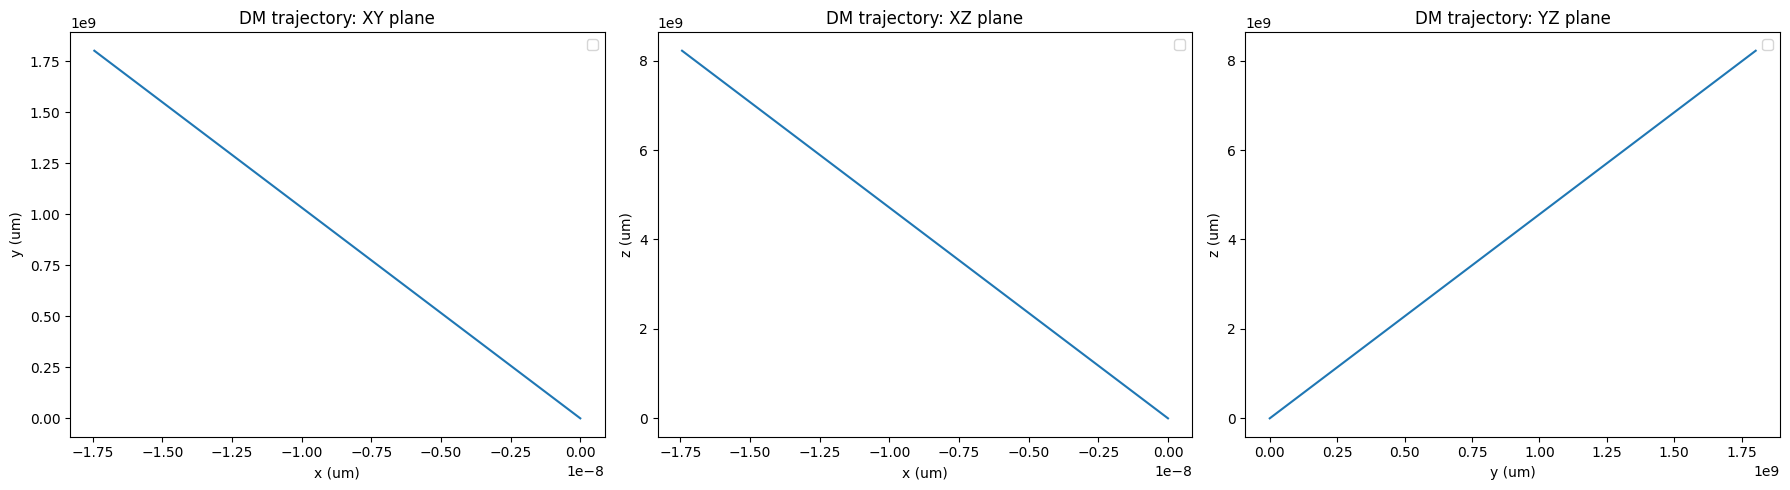

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


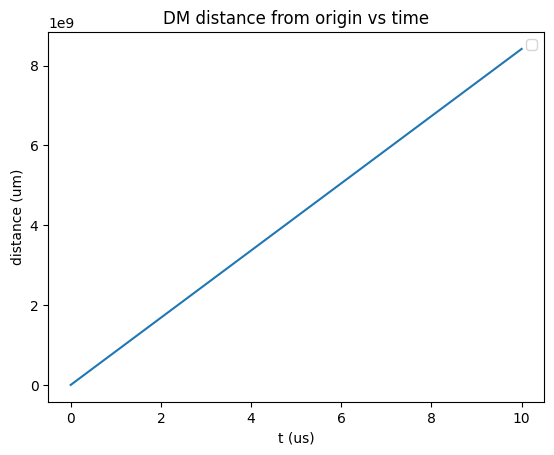

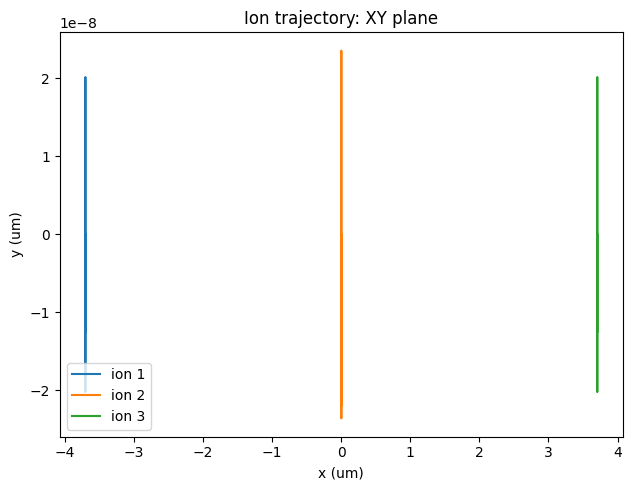

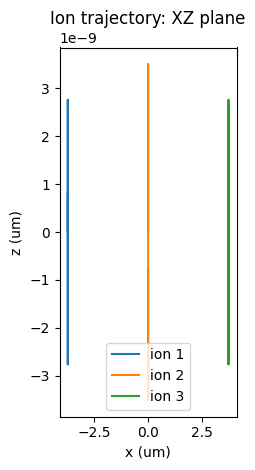

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


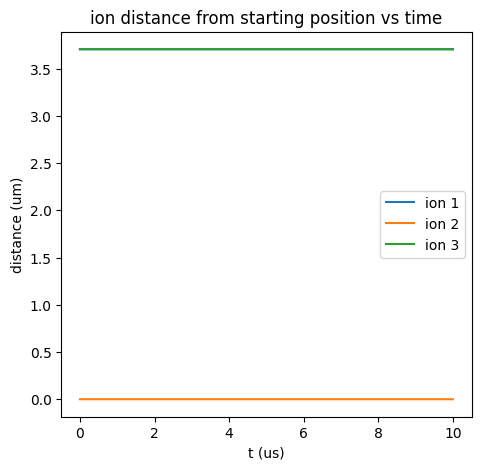

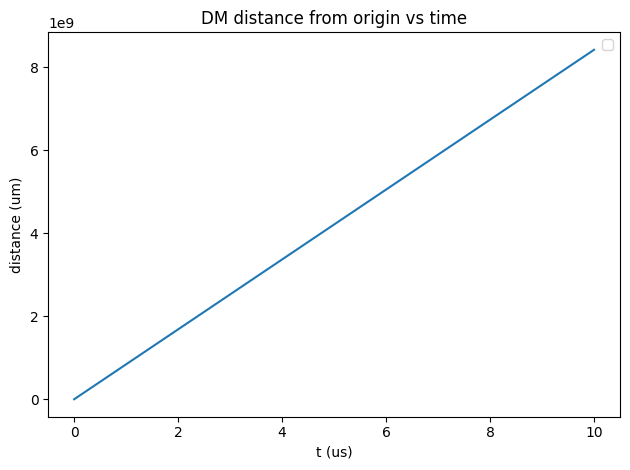

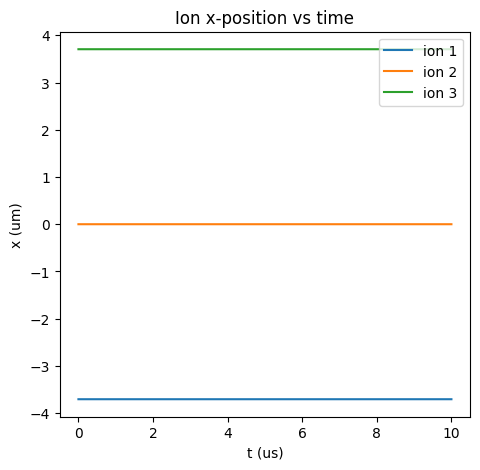

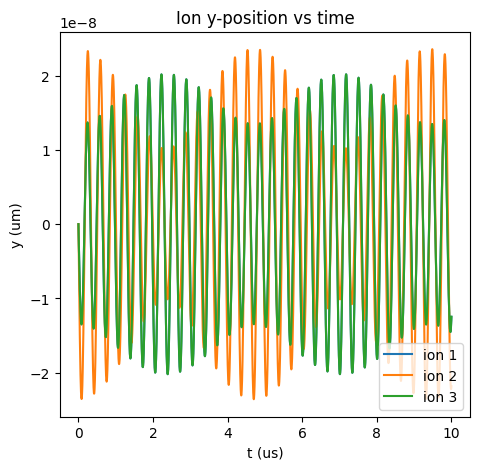

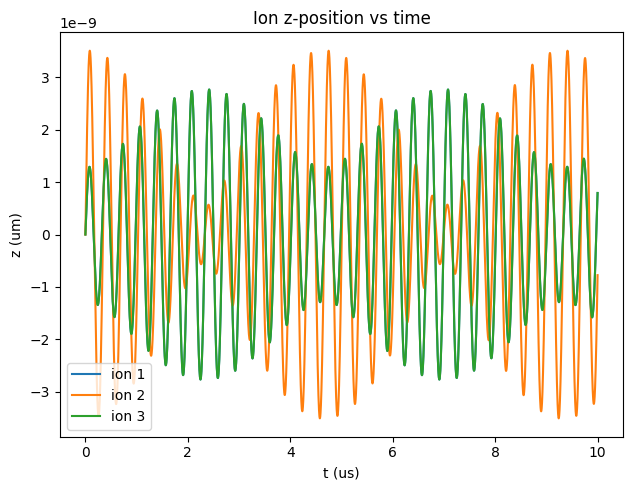

(array([0.0000e+00, 1.0000e-10, 2.0000e-10, ..., 9.9997e-06, 9.9998e-06,
        9.9999e-06], shape=(100000,)),
 array([[ 2.11297150e-22, -1.74168272e-19, -3.48547842e-19, ...,
         -1.74374336e-14, -1.74376080e-14, -1.74377824e-14],
        [-2.32848015e-06,  1.80217911e-02,  3.60459107e-02, ...,
          1.80235788e+03,  1.80237591e+03,  1.80239393e+03],
        [-3.13452024e-05,  8.21808029e-02,  1.64392951e-01, ...,
          8.22096815e+03,  8.22105036e+03,  8.22113257e+03]],
       shape=(3, 100000)),
 array([[-1.74379576e-09, -1.74379570e-09, -1.74379570e-09, ...,
         -1.74379570e-09, -1.74379570e-09, -1.74379570e-09],
        [ 1.80241199e+08,  1.80241196e+08,  1.80241196e+08, ...,
          1.80241196e+08,  1.80241196e+08,  1.80241196e+08],
        [ 8.22121480e+08,  8.22121481e+08,  8.22121481e+08, ...,
          8.22121481e+08,  8.22121481e+08,  8.22121481e+08]],
       shape=(3, 100000)),
 array([[-3.70664387e-06, -3.70664387e-06, -3.70664387e-06, ...,
         -3

In [7]:
# Run simulation
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)

b = 0e-6  # impact parameter
x0_dm = np.array([2.1129714985500633e-22, -2.3284801494144364e-06, -3.134520244349659e-05], dtype=float)
v0_dm = 1e4*np.array([-1.7437957579651323e-13, 18024.119934083286, 82212.14800628253], dtype=float)

t_span = (0, 10e-6)
dt = 1e-10
t_min = 5e-6
analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, t_min, True, False, True)


# Test Case 1: DM -> Low Velocity

Back propagate DM and obtain difference in kinetic energy 
Initial DM position: [-1.e-06 -1.e-06  0.e+00]
Initial DM velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 4.9999e-06
Ending position of DM: [  -1.52549252    9.87877297 -307.90861928] um
Ending velocity of DM: [ -0.12169135   3.0536585  -88.08440087] um/us
Interaction time for threshold 100 um: 2.6384e-06 us
Closest approach of DM to origin: 1.005627121070818 um
Difference in DM kinetic energy: 3.884e-24 J
---------------------------
Using the initial conditions from the main simulation, back propagate the DM
Initial DM position: [-1.52549252e-06  9.87877297e-06 -3.07908619e-04]
Initial DM velocity: [  0.36507405  -9.1609755  264.2532026 ]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [ 2.11050473e+00 -6.53634716e+01  2.33268315e+03] um
Ending velocity of DM: [ 

C:\Users\potha\AppData\Local\Temp\ipykernel_7340\1952859164.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_7340\1952859164.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_7340\1952859164.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


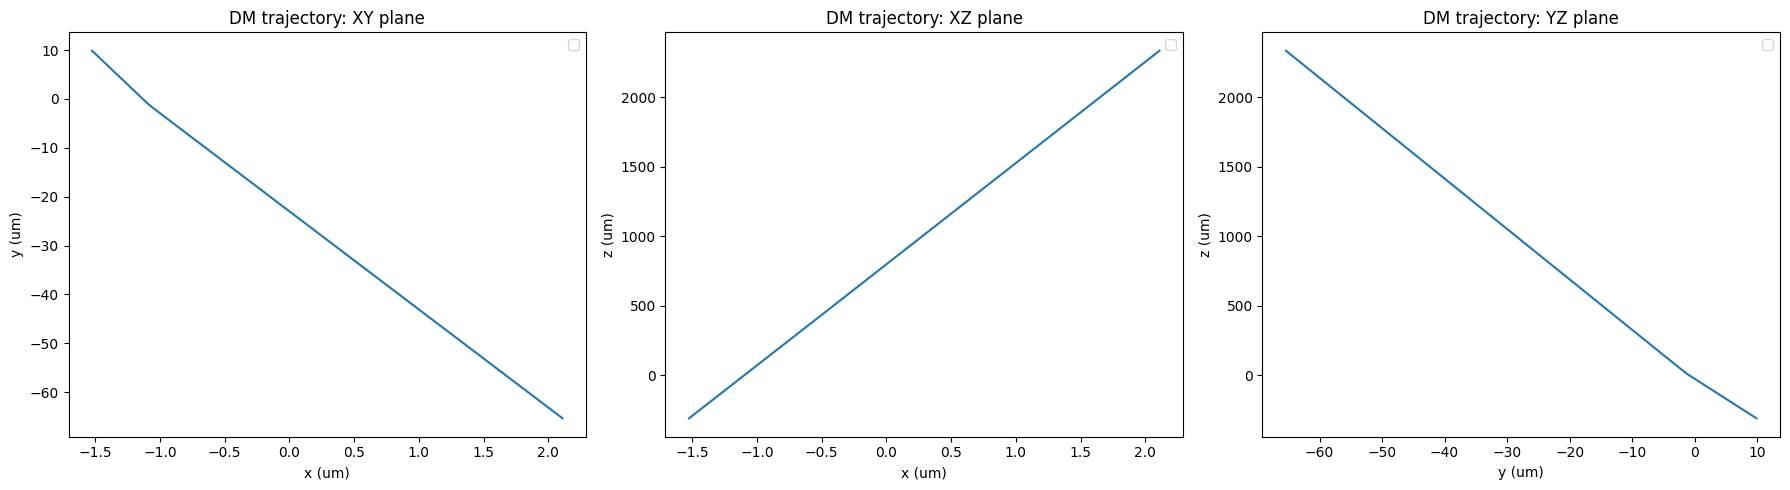

C:\Users\potha\AppData\Local\Temp\ipykernel_7340\1952859164.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


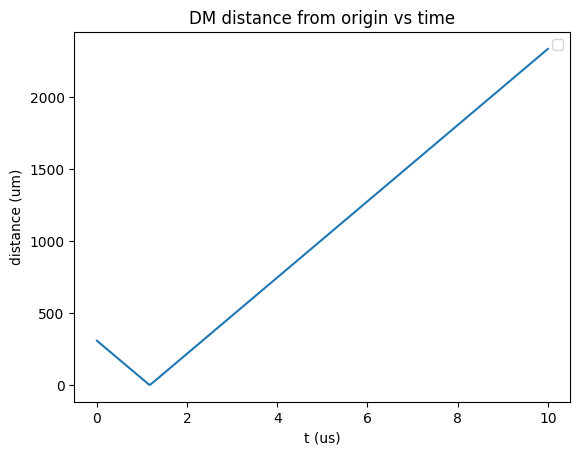

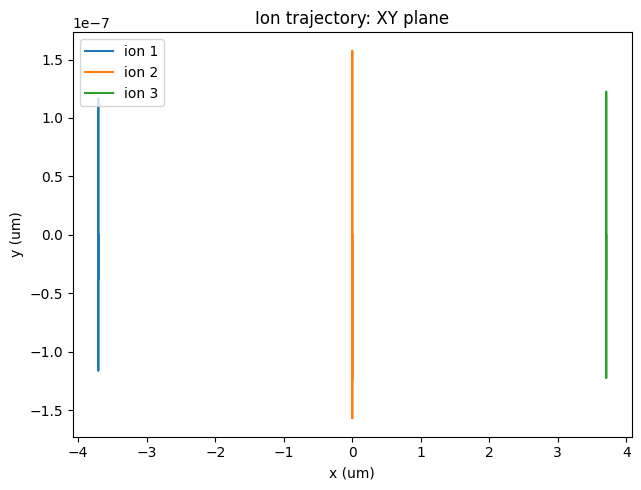

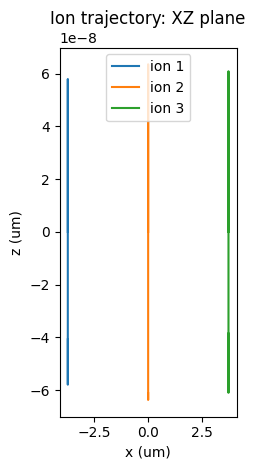

C:\Users\potha\AppData\Local\Temp\ipykernel_7340\1952859164.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


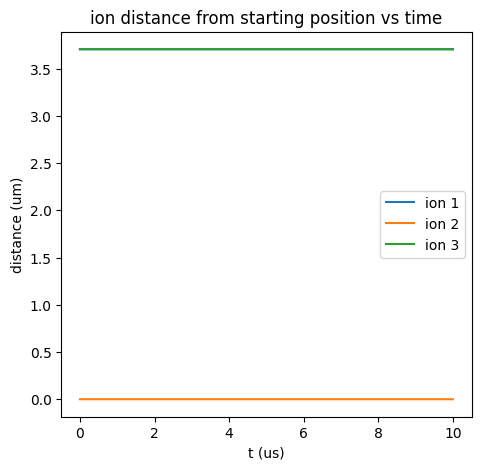

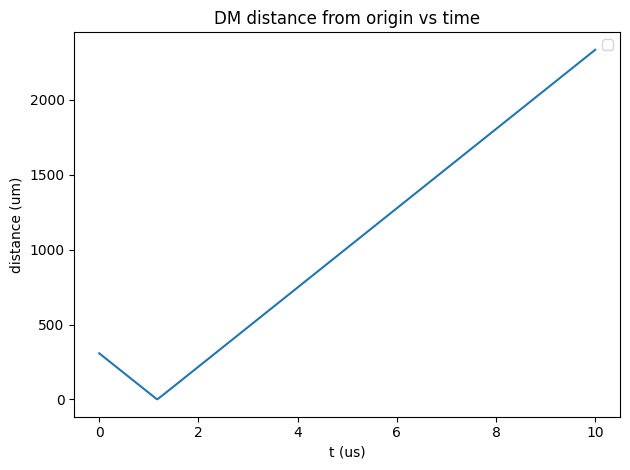

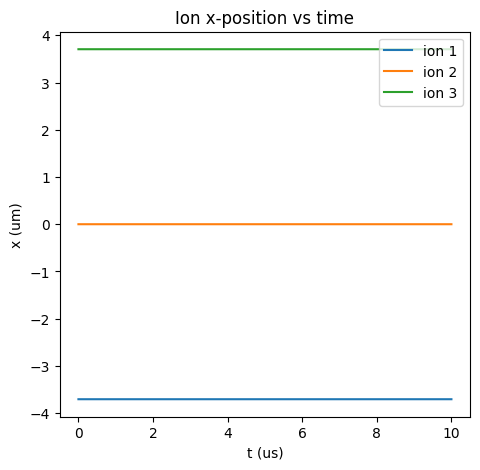

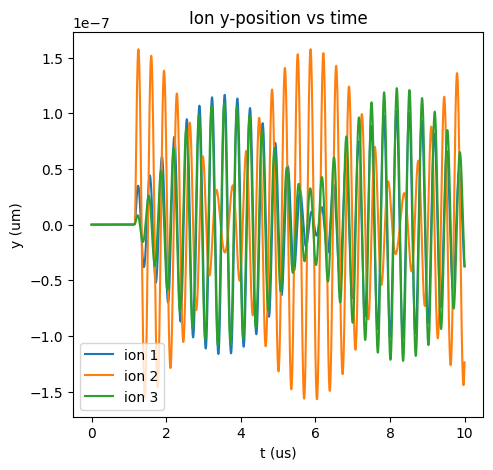

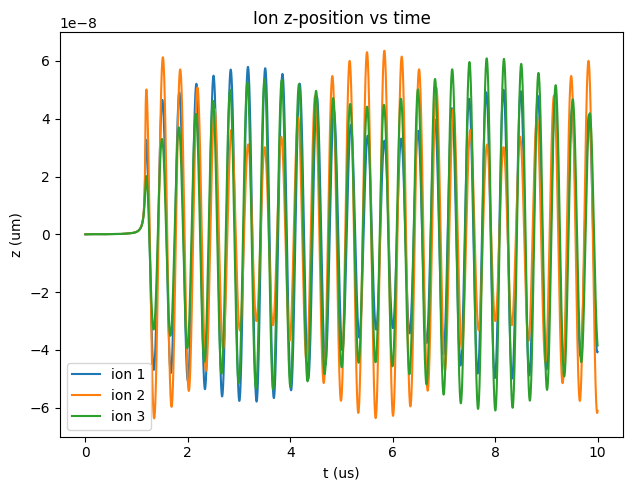

Position of DM at t=5.0e-06 s: [ 2.92348986e-07 -2.88693269e-05  1.01119886e-03] um
Velocity of DM at t=5.0e-06 s: [  0.36363659  -7.29891965 264.30068813] um/us
Difference in DM kinetic energy: -2.776e-27 J
---------------------------
At t=10.000000000000002 us:
Steady state energy of ion 1: 2.526e-36 J
Steady state energy of ion 2: 3.000e-36 J
Steady state energy of ion 3: 2.499e-36 J
Total steady state energy of ions: 4.167e-36 J


In [ ]:
### Test 1: DM moves very slowly
## Use eps = 1e-6, m_dm = 1e-27 kg (modify first cell)
## Back propagate DM and obtain difference in kinetic energy 
print(f"Back propagate DM and obtain difference in kinetic energy ")
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
x0_dm = np.array([-1e-6, -1e-6, 0], dtype=float)   
v0_dm = np.array([0, 0, 0], dtype=float)   
t_span = (0, 5e-6)
dt = 1e-10
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0,False,False,False)
E_diff = 0.5 * m_dm * np.linalg.norm(vdm0[:, -1])**2 - 0.5 * m_dm * np.linalg.norm(v0_dm)**2
print(f"Difference in DM kinetic energy: {E_diff:.3e} J")

## Using the initial conditions from the main simulation, forward propagate the DM
print("---------------------------")
print(f"Using the initial conditions from the main simulation, forward propagate the DM")
x0_dm = xdm0[:, -1]
v0_dm = -3*vdm0[:, -1]
index = (int)(t_span[1]/dt)
t_span = (0, 1e-5)  # New time scale
t_min = 0;
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,t_min,False,False,True)
# check that the difference in kinetic energy is the same (opposite sign) as before at the end of the old timespan
E_diff = 0.5 * m_dm * np.linalg.norm(vdm0[:, index])**2 - 0.5 * m_dm * np.linalg.norm(v0_dm)**2
print(f"Position of DM at t={dt*index:.1e} s: {xdm0[:, index]} um")
print(f"Velocity of DM at t={dt*index:.1e} s: {vdm0[:, index]} um/us")
print(f"Difference in DM kinetic energy: {E_diff:.3e} J")
# Steady state energy of ions
index_min = (int)((t_min-t_span[0])/dt);
E_ion1 = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
E_ion2 = 0.5 * m_ion * (vion0[3]**2 + vion0[4]**2 + vion0[5]**2)
E_ion3 = 0.5 * m_ion * (vion0[6]**2 + vion0[7]**2 + vion0[8]**2)
E_ion1 = E_ion1[index_min:]
E_ion2 = E_ion2[index_min:]
E_ion3 = E_ion3[index_min:]
print("---------------------------")
print(f"At t={t_span[1]/um} us:")
print(f"Steady state energy of ion 1: {max(E_ion1):.3e} J")
print(f"Steady state energy of ion 2: {max(E_ion2):.3e} J")
print(f"Steady state energy of ion 3: {max(E_ion3):.3e} J")
print(f"Total steady state energy of ions: {max(E_ion1) + max(E_ion2) + max(E_ion3)} J")

# Test Case 2: Dark Matter-> high velocity

Initial DM position: [-1.52549252e-06  9.87877297e-06 -3.07908619e-04]
Initial DM velocity: [  121691.35       -3053658.5        88084400.86999999]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [ 1.21689981e+06 -3.05362698e+07  8.80834892e+08] um
Ending velocity of DM: [  121691.35       -3053658.49999482 88084400.87000012] um/us
Interaction time for threshold 100 um: 0.0 us
Closest approach of DM to origin: 308.07082779339646 um


C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


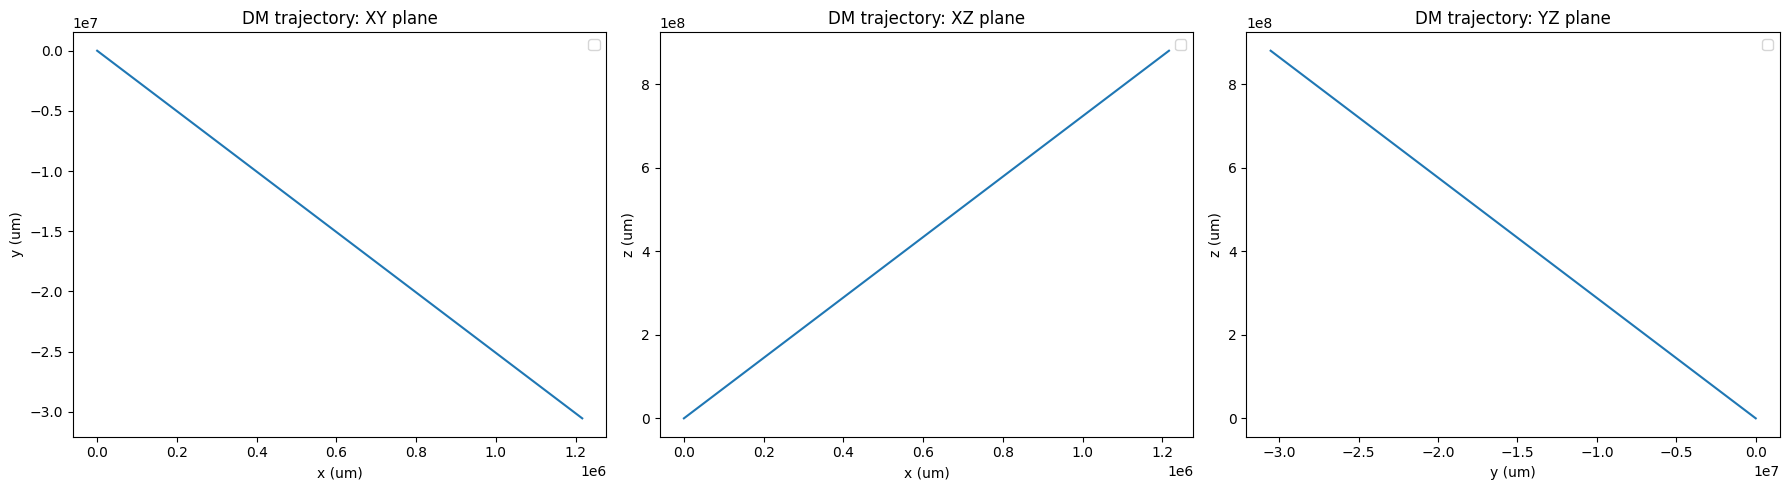

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


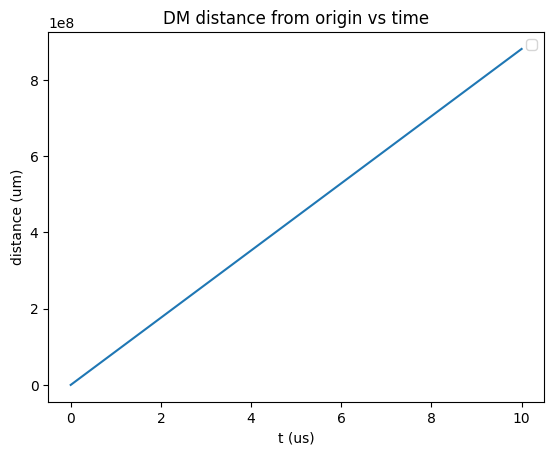

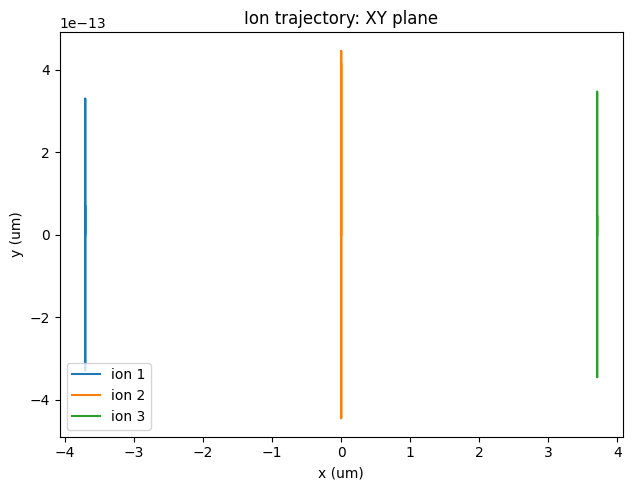

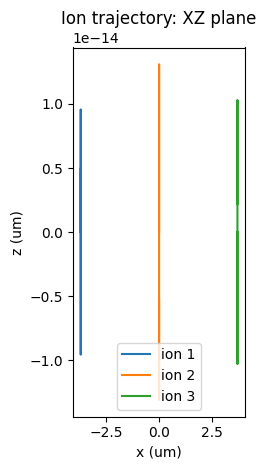

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


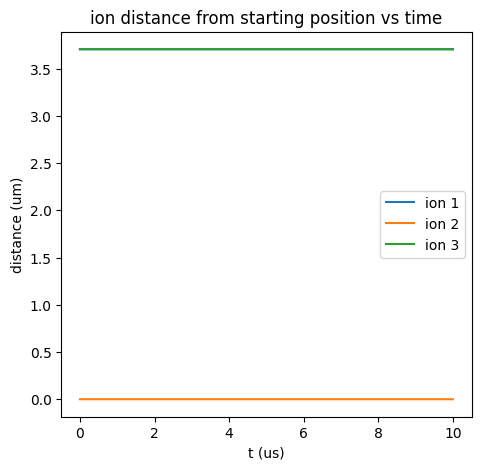

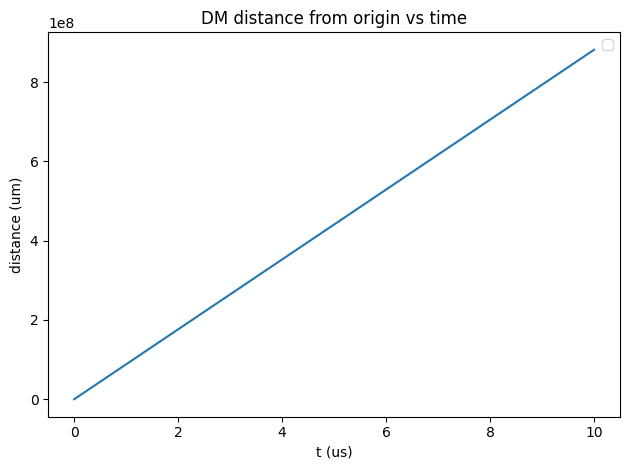

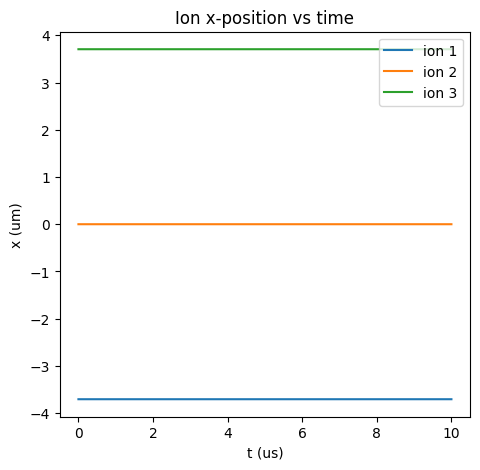

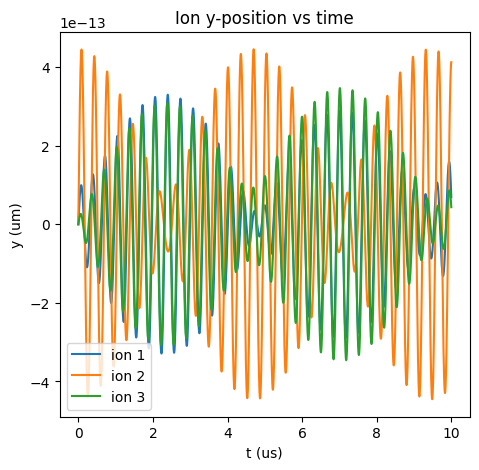

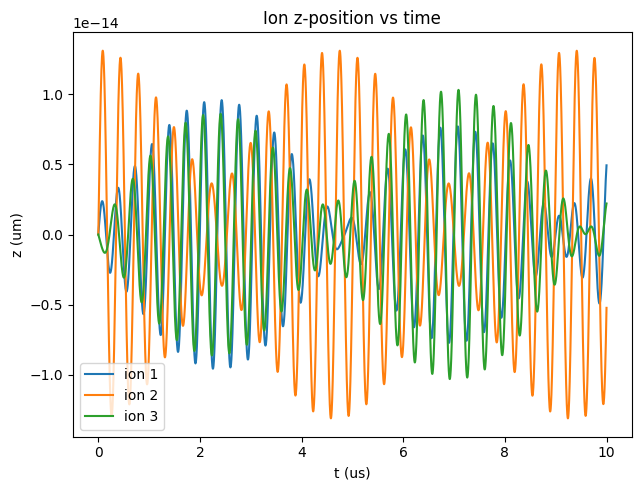

At t=10.000000000000002 us:
Observed energy of ion 1 after interaction: 6.205771987978839e-41 J
Observed energy of ion 2 after interaction: 2.74965060935433e-47 J
Observed energy of ion 3 after interaction: 6.205755791295184e-41 J
Observed total energy of ions after interaction: 1.241153052892463e-40 J
Effective initial velocities of ions after DM passes by: [[-1.70265131e-10  2.02175741e-12  4.87054177e-14]
 [ 1.12783329e-11  8.14735604e-12  2.36313449e-13]
 [ 1.67460232e-10  6.33426971e-13 -1.38844601e-14]] um/us
Initial DM position: [-1.52549252e-06  9.87877297e-06 -3.07908619e-04]
Initial DM velocity: [  121691.35       -3053658.5        88084400.86999999]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [ 1.21689981e+06 -3.05362698e+07  8.80834892e+08] um
Ending velocity of DM: [  121691.35       -3053658.5        88084400.86999999] um/us
Interaction time for threshold 100 um: 0.0 us
Closest a

In [28]:
### Test 2: DM moves very quickly
## Run simulation/analyze results
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
b = 2e-4  # impact parameter
x0_dm = np.array([-1.52549252e-06, 9.87877297e-06, -3.07908619e-04], dtype=float) # extension of test case 1
v0_dm = 1e6 * np.array([0.12169135, -3.0536585, 88.08440087], dtype=float)
#x0_dm = np.array([-1e-3,b,0], dtype=float)
#v0_dm = np.array([1e9,0,0], dtype=float)
t_span         = (0.0, 1e-5)  # (0,1e-5)
dt             = 1e-10 
t_min = 0;
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,t_min, False, False, True)

## Energy of ions after interaction
# Observed
index_min = (int)((t_min-t_span[0])/dt);
E_ion1 = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
E_ion2 = 0.5 * m_ion * (vion0[3]**2 + vion0[4]**2 + vion0[5]**2)
E_ion3 = 0.5 * m_ion * (vion0[6]**2 + vion0[7]**2 + vion0[8]**2)
E_ion1 = E_ion1[index_min:]
E_ion2 = E_ion2[index_min:]
E_ion3 = E_ion3[index_min:]
print(f"At t={t_span[1]/um} us:")
print(f"Observed energy of ion 1 after interaction: {max(E_ion1)} J")
print(f"Observed energy of ion 2 after interaction: {max(E_ion2)} J")
print(f"Observed energy of ion 3 after interaction: {max(E_ion3)} J")
print(f"Observed total energy of ions after interaction: {max(E_ion1) + max(E_ion2) + max(E_ion3)} J")
vion_initial = np.array(vion0[:, 10]).reshape((3, 3))
print(f"Effective initial velocities of ions after DM passes by: {vion_initial} um/us") # Used for next part of test
# Free space
x0_ions = np.array([delta_ion_2, 0, 0], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0, False, True, False)
E_ion_fs = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
print(f"Free-space total of ion after interaction: {E_ion_fs[-1]} J")


Initial DM position: [-1.52549252e-06  9.87877297e-06 -3.07908619e-04]
Initial DM velocity: [  121691.35       -3053658.5        88084400.86999999]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [ 1.21689981e+06 -3.05362698e+07  8.80834892e+08] um
Ending velocity of DM: [  121691.35       -3053658.5        88084400.86999999] um/us
Interaction time for threshold 100 um: 0.0 us
Closest approach of DM to origin: 308.07082779339646 um


C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


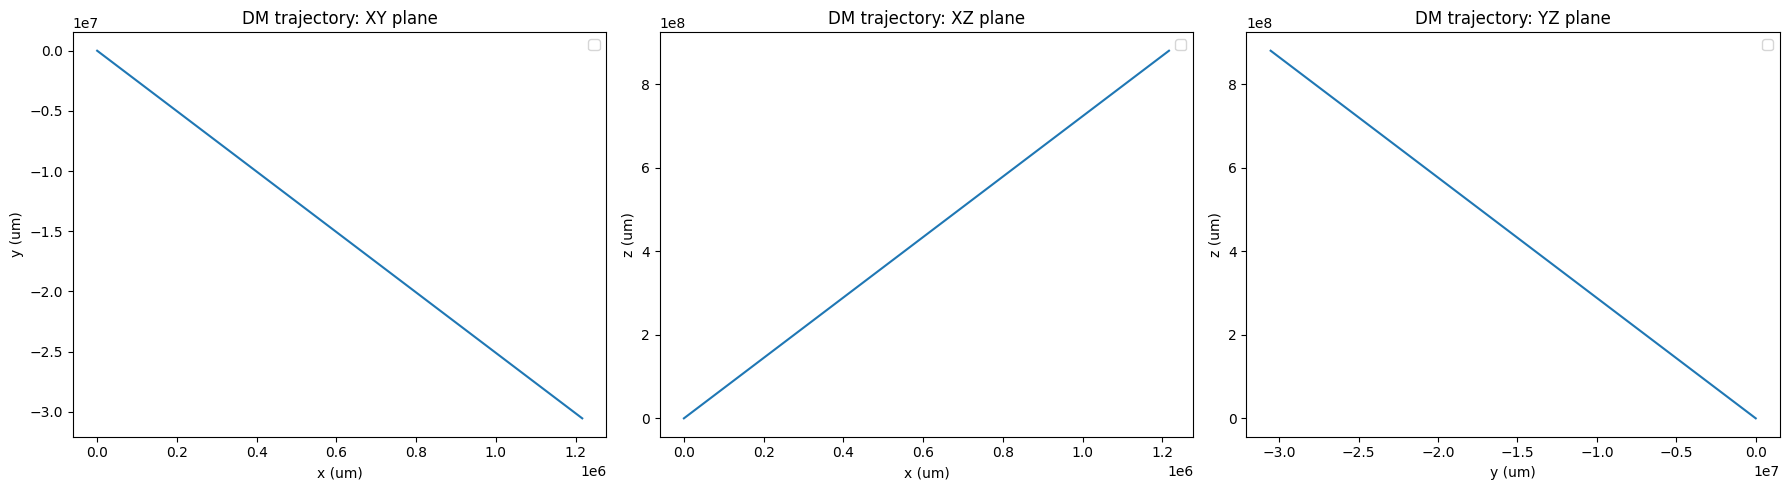

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


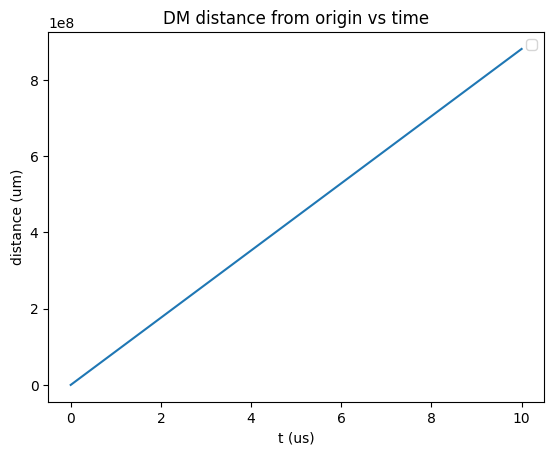

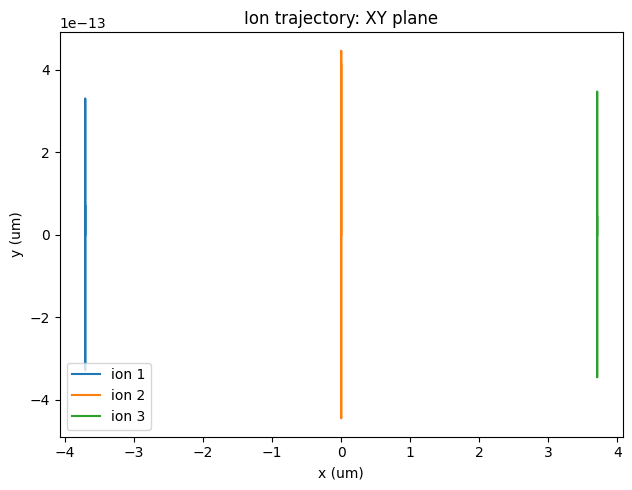

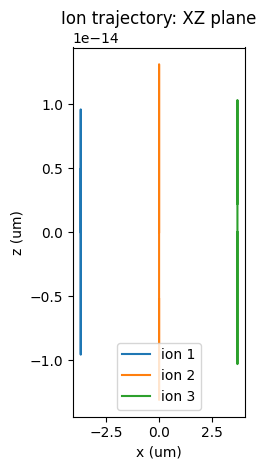

C:\Users\potha\AppData\Local\Temp\ipykernel_6328\4200066969.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


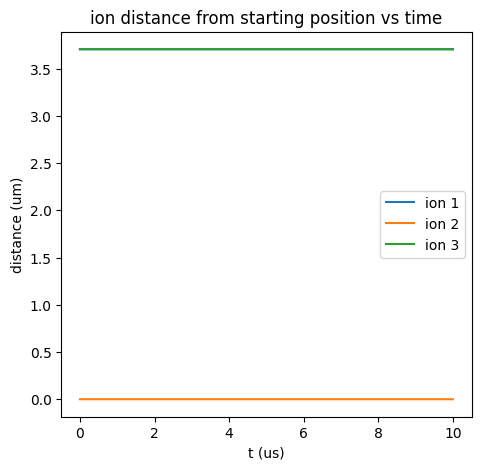

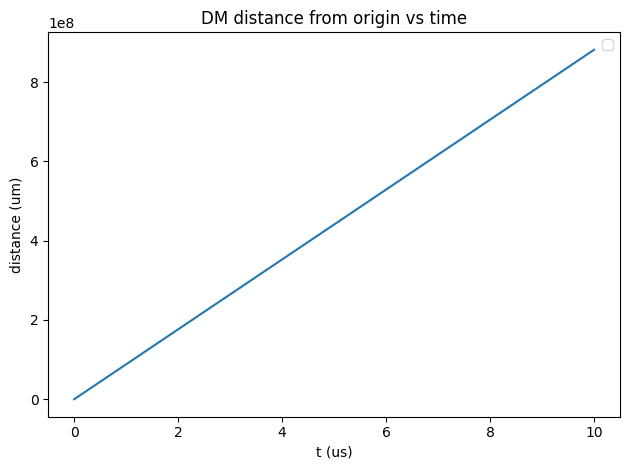

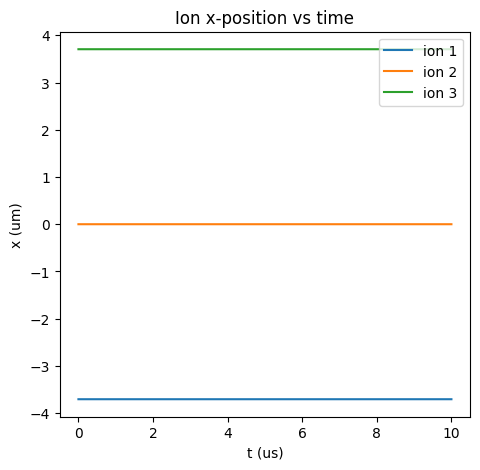

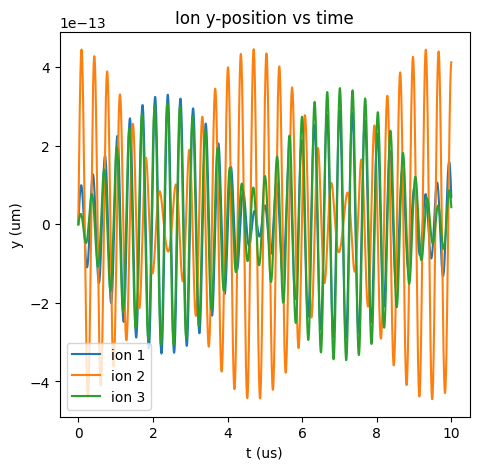

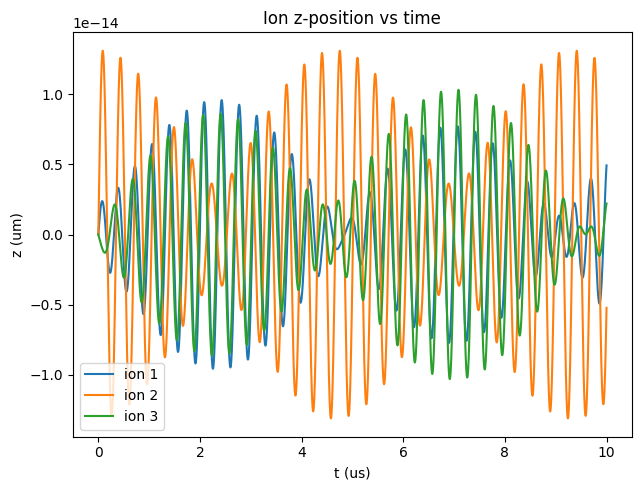

At t=10.000000000000002 us:
Observed energy of ion 1 after interaction: 6.206177153066871e-41 J
Observed energy of ion 2 after interaction: 2.7491688968019313e-47 J
Observed energy of ion 3 after interaction: 6.20617212528407e-41 J
Observed total energy of ions after interaction: 1.2412352027519837e-40 J


In [34]:
## Repeat the simulation, treating it as an initial value problem using the velocity of the ions after the DM passes by, and check that the energy of the ions is the same as before
# Set eps = 0
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = vion_initial
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,t_min, False, False, True)
index_min = (int)((t_min-t_span[0])/dt);
E_ion1 = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
E_ion2 = 0.5 * m_ion * (vion0[3]**2 + vion0[4]**2 + vion0[5]**2)
E_ion3 = 0.5 * m_ion * (vion0[6]**2 + vion0[7]**2 + vion0[8]**2)
E_ion1 = E_ion1[index_min:]
E_ion2 = E_ion2[index_min:]
E_ion3 = E_ion3[index_min:]
print(f"At t={t_span[1]/um} us:")
print(f"Observed energy of ion 1 after interaction: {max(E_ion1)} J")
print(f"Observed energy of ion 2 after interaction: {max(E_ion2)} J")
print(f"Observed energy of ion 3 after interaction: {max(E_ion3)} J")
print(f"Observed total energy of ions after interaction: {max(E_ion1) + max(E_ion2) + max(E_ion3)} J")

# Test Case 3 : Maximum Amplitude at Resonant Condition

In [6]:

import scipy.integrate
_original_solve_ivp = scipy.integrate.solve_ivp

def _loose_solve_ivp(*args, **kwargs):
    kwargs['rtol'] = 1e-9
    kwargs['atol'] = 1e-12
    return _original_solve_ivp(*args, **kwargs)

solve_ivp = _loose_solve_ivp   

omega_y = omega[1]
T = 2*pi/omega_y
b = 2e-4
xi_star = 1.25
v_res = omega_y * b / xi_star
print(f"Resonant velocity: {v_res:.3e} m/s")

velocities = {
    "below resonance": v_res / 3,   # xi ~ 3.75
    "resonant":        v_res,        # xi ~ 1.25
    "above resonance": v_res * 3,    # xi ~ 0.417
}

n_periods = 20
n_periods_impact = 10
dt = T / 50
t_span = (0.0, n_periods * T)

amplitudes = {}

try:
    for label, v in velocities.items():
        x0_ions = np.array([
            [-d_chain, 0, 0],
            [delta_ion_2, 0, 0],
            [d_chain, 0, 0]
        ], dtype=float)
        v0_ions = np.zeros_like(x0_ions, dtype=float)

        x0_dm = np.array([-v * n_periods_impact * T, b, 0], dtype=float)
        v0_dm = np.array([v, 0, 0], dtype=float)

        xi = omega_y * b / v
        t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(
            x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, 0, False, False, False
        )
        y_ion2 = xion0[4]

        t_mid = n_periods_impact * T
        post_mask = t0 > (t_mid + 5 * T)
        peak_amp = np.max(np.abs(y_ion2[post_mask]))

        amplitudes[label] = peak_amp
        print(f"Peak residual |y| amplitude of ion 2 (post-encounter): {peak_amp:.3e} m\n")
finally:
    solve_ivp = _original_solve_ivp  

print("=== Summary ===")
for label, amp in amplitudes.items():
    print(f"  {label:20s}: {amp:.3e} m")

Resonant velocity: 3.047e+03 m/s
Initial DM position: [-0.00335103  0.0002      0.        ]
Initial DM velocity: [1015.76487282    0.            0.        ]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 6.591448909566378e-06
Ending position of DM: [ 3.34446687e+03  4.31230352e+02 -1.96519849e+00] um
Ending velocity of DM: [ 1.01579063e+03  3.92900167e+01 -2.94276744e-01] um/us
Interaction time for threshold 100 um: 0.0 us
Closest approach of DM to origin: 302.22332120067 um
Peak residual |y| amplitude of ion 2 (post-encounter): 5.126e-18 m

Initial DM position: [-0.0100531  0.0002     0.       ]
Initial DM velocity: [3047.29461846    0.            0.        ]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 6.591448909566378e-06
Ending position of DM: [1.00330244e+04 4.31239426e+02 5.41806460e-01] um
Ending velocity of DM: [3.04730322e+03 3.92892892e+01 2.12167590e-01] um/us